<a href="https://colab.research.google.com/github/SkyZhou-1/bug-free-journey/blob/main/%5BLight_VME50%5DMilestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Section 1: link with github and install what we provide
tips: only need run this section once

In [ ]:
!git clone https://github.com/tianjingwen2000/WMCodec-M2.git

Cloning into 'WMCodec-M2'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 77 (delta 15), reused 39 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 104.41 KiB | 8.70 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [ ]:
!pip install -r WMCodec-M2/WMCodec/requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 131.9 MB/s eta 0:00:00
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284115 sha256=64502a7ede144b119202ffaa9dbbef9b000cdbadf336ce469262d49c7451b561
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq
  Attempting uninstall: librosa
    Found existing installation: librosa 0.11.0
    Uninstalling librosa-0.11.0:
      Successfully uninstalled librosa-0.11.0


In [ ]:
!git lfs install
!git clone https://huggingface.co/zjzser/WMCodec WMCodec_hc

Git LFS initialized.
Cloning into 'WMCodec_hc'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 22 (delta 2), reused 0 (delta 0), pack-reused 3 (from 1)
Unpacking objects: 100% (22/22), 8.04 KiB | 228.00 KiB/s, done.
Filtering content: 100% (2/2), 2.16 GiB | 52.35 MiB/s, done.


#Section 2: Upload your audio file
You can upload .mp3, .mp4, .flac or .wav file

In [ ]:
# Upload the local mp3/wav/m4a/flac file
# then convert them to 24kHz mono wav format and store into /content/input_audio/resampled_audio.wav
from google.colab import files
import os, librosa, soundfile as sf, numpy as np

# Target sampling rate(Hz)
TARGET_SR = 24000

# Fix the output directory and output file name
OUT_DIR   = "/content/input_audio"
OUT_NAME  = "resampled_audio.wav"

# If the directory does not exist, create it and make sure it can be written to the output file
os.makedirs(OUT_DIR, exist_ok=True)

def convert_to_fixed(src_path, dst_dir=OUT_DIR, target_sr=TARGET_SR, out_name=OUT_NAME):
    """
    Read audio file that can be decoded by librosa:
    1. Convert to mono
    2. Resample to target_sr (which is 24 kHz)
    3. Apply slight peak normalization to avoid clipping
    4. Write to the specified directory with a fixed file name
     1) 转单声道；2) 重采样到 24 kHz；
    3) 轻微峰值归一化避免削波；4) 固定文件名写出
    """
    # Read in and resampled to mono
    y, sr = librosa.load(src_path, sr=target_sr, mono=True)
    # Avoid clipping
    peak = np.max(np.abs(y)) if y.size else 0.0
    if peak > 0:
        y = 0.99 * y / peak
    # Fixed output path: /content/input_audio/resampled_audio.wav
    dst = os.path.join(dst_dir, out_name)
    sf.write(dst, y, target_sr)
    return dst

uploaded = files.upload()  # Choose your file
last_out = None
for name, data in uploaded.items():
    # Save the uploaded original file to the current directory first
    with open(name, "wb") as f:
        f.write(data)
    # Convert and fix the output as /content/input_audio/resampled_audio.wav
    last_out = convert_to_fixed(name)

print(f"A fixed file has been output: {last_out}")


Saving FiveSonChess.mp3 to FiveSonChess.mp3
A fixed file has been output: /content/input_audio/resampled_audio.wav


Check the Sampling Rate and Audio Length

In [ ]:
import librosa

# Load the audio and check the sampling rate
y, sr = librosa.load('/content/input_audio/resampled_audio.wav', sr=None)

print(f"Sampling Rate: {sr}")
print(f"Audio Length: {len(y)}")


Sampling Rate: 24000
Audio Length: 345024


#Section 3: Run the inference script of WMCodec


## 3.1: Generate Attacked/Non-Attacked WM audio file

For this part, there are 4 attack types, if you don't have idea about how to attack, you can choose any kind of attack that we provide. (you can modify the parameter)

What you need to do: choose any kind of attack, and copy them, then paste them into "#replace this line"

In [ ]:
!rm -f results_demo/results.csv

!python WMCodec-M2/WMCodec/inference-at.py \
  --input_wavs_dir input_audio \
  --output_dir results_demo \
  --checkpoint_file WMCodec_hc/save_model/g_00150000 \
  --run_id m2 \
  --attack_type none   #replace this line
  #--attack_type reverb
  #--attack_type resample --target_sr 16000
  #--attack_type mp3 --bitrate 16000
  #--attack_type gaussian --snr_db 1
  #--attack_type none


Initializing Inference Process..
Loading 'WMCodec_hc/save_model/g_00150000'
Complete.
filelist:  1
Removing weight norm...
Removing weight norm...
device :  cuda:0
/usr/local/lib/python3.12/dist-packages/torch/functional.py:730: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:875.)
  return _VF.stft(  # type: ignore[attr-defined]
No CLIP statistics
audiomark_loss:
Opera CLP iter 5 value tensor(2.9521e-05, device='cuda:0')
Opera RSP-90 iter 11 value tensor(3.0087e-05, device='cuda:0')
Opera Noise-W35 iter 7 value tensor(5.8992e-05, device='cuda:0')
Opera SS-01 iter 10 value tensor(5.0629e-05, device='cuda:0')
Opera AS-90 iter 8 value tensor(3.3641e-05, device='cuda:0')
Opera EA-0301 ite

##3.2: Visualization

The left side bar chart is CE (cross entropy), the smaller the value, the closer the prediction is to the actual bit sequence.


The right side bar chart is ACC (accuracy), it use to measure the degree of matching between the decoded bit sequence and the original watermark bits. The closer to 1, the more stable the watermark is under these conditions.

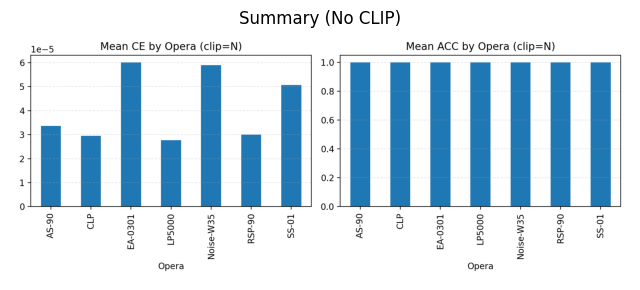

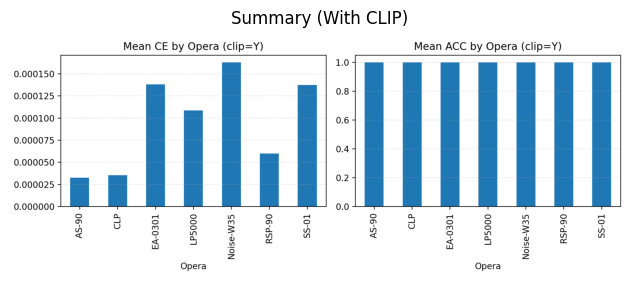

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display the result without clip
img = mpimg.imread("results_demo/results_summary_clip_N.png")
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Summary (No CLIP)")
plt.show()

# Load and display the result with clip
img = mpimg.imread("results_demo/results_summary_clip_Y.png")
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Summary (With CLIP)")
plt.show()


#Section 4: Test your attack
You can test your own attack here. But be sure you have an original WM audio.

目的：

用“未被攻击的带水印音频”解码出参考位串（作为“真值”）

批量上传被攻击的音频，对每个音频做解码并与参考位串对齐，计算 ACC/BER，判断水印完好/破坏

##4.1: Setting
载入解码器；一次性运行
tips: only need to run it one time

In [ ]:
# Load configuration with decoder (run only once)
import os, sys, json, torch

sys.path.append("/content/WMCodec-M2/WMCodec")

from env import AttrDict
from meldataset import mel_spectrogram
from watermark import Watermark_Decoder

CKPT   = "WMCodec_hc/save_model/g_00150000"
CONFIG = os.path.join(os.path.dirname(CKPT), "config.json")

with open(CONFIG, "r") as f:
    h = AttrDict(json.load(f))

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

wm_dec = Watermark_Decoder(h).to(device)
state  = torch.load(CKPT, map_location=device)
wm_dec.load_state_dict(state["watermark_decoder"])
wm_dec.eval()

print("Decoder loaded on", device)
print("Sampling rate:", h.sampling_rate)


Decoder loaded on cuda:0
Sampling rate: 24000


##4.2: Transfer non-attacked audio file to .wm.json
生成参考位串 Reference bits：从“未攻击”的带水印音频得到

In [ ]:
# Generate the same name from the baseline audio: .wm.json
import numpy as np, torch, librosa, json, pathlib, gc
from google.colab import files
from meldataset import mel_spectrogram

TARGET_SR = h.sampling_rate

def preprocess_audio(path, target_sr=TARGET_SR):
    y, sr = librosa.load(path, sr=target_sr, mono=True, dtype=np.float32)
    peak = np.max(np.abs(y)) if y.size else 0.0
    if peak > 0:
        y = 0.99 * y / peak
    return torch.from_numpy(y).to(device).view(1,1,-1)  # [1,1,T]

def decode_bits(x):
    mel = mel_spectrogram(
        x.squeeze(1),
        h.n_fft, h.num_mels, h.sampling_rate,
        h.hop_size, h.win_size, h.fmin, h.fmax_for_loss
    )
    _, sign_hat = wm_dec(mel)
    return sign_hat.detach().cpu().numpy().astype(int).reshape(-1)

print("please upload your *Not attacked, only embedded with a watermark baseline audio*（.wav/.flac/.mp3/.m4a）：")
base_uploaded = files.upload()
base_name = next(iter(base_uploaded.keys()))

# 解码并写出 .wm.json（后面作为“真值”用）
x = preprocess_audio(base_name)
gt_bits = decode_bits(x)
meta = {"bit_num": int(len(gt_bits)), "bits": gt_bits.tolist()}

json_path = pathlib.Path(base_name).with_suffix(".wm.json")
with open(json_path, "w") as f:
    json.dump(meta, f)
print("Generated GT file：", json_path)

# Release temporary memorydel
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()


please upload your *Not attacked, only embedded with a watermark baseline audio*（.wav/.flac/.mp3/.m4a）：


Saving resampled_audio.wav to resampled_audio.wav
Generated GT file： resampled_audio.wm.json


83

##4.3: ACC/BER 指标 + 小范围对齐
被攻击音频可能出现轻微“失步”（裁剪/变速/重采样），所以我们允许**±64 位的小范围平移对齐**，算出最优 BER，再得 ACC。

这一步是评测助手函数，和你“test your attack”的目标一致（只是更稳健）

In [ ]:
# 4.3 · Metrics helpers (ACC/BER) + verdict + small utils
import numpy as np, json, pathlib

def acc_and_ber(decoded_bits, gt_bits, try_sync=True, max_shift=64):
    """
    Return (ACC, BER). When lengths differ, try small translation alignment
    within ±max_shift to minimize BER. (use 64 for stronger sync)
    """
    if gt_bits is None:
        return None, None

    a = np.asarray(decoded_bits).astype(int)
    b = np.asarray(gt_bits).astype(int)

    if len(a) == 0 or len(b) == 0:
        return None, None

    if len(a) == len(b):
        acc = float((a == b).mean())
        ber = float((a != b).mean())
        return acc, ber

    if try_sync:
        L = min(len(a), len(b))
        aL, bL = a[:L], b[:L]
        best_ber = 1.0
        for s in range(-max_shift, max_shift + 1):
            if s >= 0:
                aa = aL[s:]; bb = bL[:len(aa)]
            else:
                bb = bL[-s:]; aa = aL[:len(bb)]
            if len(aa) == 0:
                continue
            ber = float((aa != bb).mean())
            if ber < best_ber:
                best_ber = ber
        if best_ber < 1.0:
            return 1.0 - best_ber, best_ber

    return None, None

def watermark_verdict(acc, ber, acc_thr=0.95, ber_thr=0.05):
    """Return 'intact' / 'broken' / 'unverifiable'"""
    if acc is None or ber is None:
        return 'unverifiable'
    return 'intact' if (acc >= acc_thr and ber <= ber_thr) else 'broken'

def load_gt_bits_from_json(json_path: str):
    p = pathlib.Path(json_path)
    if p.exists():
        obj = json.loads(p.read_text())
        return np.array(obj.get("bits", []), dtype=int).reshape(-1)
    return None

def load_gt_bits_if_any(wav_path: str):
    """兼容你原逻辑：尝试用与音频同名的 .wm.json（如果你把 ref 复制改名了也可用）"""
    p = pathlib.Path(wav_path)
    meta = p.with_suffix(".wm.json")
    if meta.exists():
        try:
            obj = json.loads(meta.read_text())
            return np.array(obj.get("bits", []), dtype=int).reshape(-1)
        except Exception:
            return None
    return None

## 4.4 Evaluate attacked audios: decode + ACC/BER + verdict

In [ ]:
# 4.4 · Evaluate attacked audios: decode + ACC/BER + verdict
from google.colab import files
import numpy as np, torch, librosa, json, pathlib, gc
import pandas as pd
from meldataset import mel_spectrogram

TARGET_SR = h.sampling_rate

def preprocess_audio(path, target_sr=TARGET_SR):
    y, sr = librosa.load(path, sr=target_sr, mono=True, dtype=np.float32)
    peak = np.max(np.abs(y)) if y.size else 0.0
    if peak > 0:
        y = 0.99 * y / peak
    return torch.from_numpy(y).to(device).view(1,1,-1)

def decode_bits(x):
    mel = mel_spectrogram(
        x.squeeze(1),
        h.n_fft, h.num_mels, h.sampling_rate,
        h.hop_size, h.win_size, h.fmin, h.fmax_for_loss
    )
    _, sign_hat = wm_dec(mel)
    return sign_hat.detach().cpu().numpy().astype(int).reshape(-1)

print("Please upload: attacked .wav/.mp3/.m4a/.flac files, "
      "AND the reference .wm.json produced in 4.2 (same basename as the *baseline* audio).")
uploaded = files.upload()

# 优先使用你上传的“参考 .wm.json”作为所有 attacked 的真值
ref_json_path = None
for fname in uploaded.keys():
    if fname.endswith(".wm.json"):
        ref_json_path = fname
        break

if ref_json_path:
    ref_bits = load_gt_bits_from_json(ref_json_path)
    print("Using reference bits from:", ref_json_path, f"(len={len(ref_bits) if ref_bits is not None else 0})")
else:
    ref_bits = None
    print("⚠️ 未上传参考 .wm.json，将退回到“按 attacked 同名 .wm.json”逐个尝试（更容易不一致）。")

results = []
audio_exts = {".wav", ".flac", ".mp3", ".m4a"}

for name in sorted(uploaded.keys()):
    if pathlib.Path(name).suffix.lower() not in audio_exts:
        continue
    try:
        x = preprocess_audio(name)
        decoded = decode_bits(x)
        # 1) 若有统一参考 .wm.json，用它；2) 否则尝试同名 .wm.json
        gt = ref_bits if ref_bits is not None else load_gt_bits_if_any(name)
        acc, ber = acc_and_ber(decoded, gt, try_sync=True, max_shift=64)
        verdict = watermark_verdict(acc, ber)

        # 打印时截断位串，避免刷屏
        head = 32
        dec_head = decoded[:head]
        print(f"[{name}] decoded(head{head})={dec_head} ...  ACC={acc}  BER={ber}  → {verdict.upper()}")

        results.append((name, len(decoded), len(gt) if gt is not None else None, acc, ber, verdict))
    finally:
        del x
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

df_eval = pd.DataFrame(results, columns=["file","decoded_len","gt_len","ACC","BER","verdict"])
df_eval = df_eval.sort_values(["verdict","ACC"], ascending=[True, False])
display(df_eval)

# （可选）保存评测表
df_eval.to_csv("attack_eval_summary.csv", index=False)
print("Saved: attack_eval_summary.csv")


Please upload: attacked .wav/.mp3/.m4a/.flac files, AND the reference .wm.json produced in 4.2 (same basename as the *baseline* audio).


Saving 32resampled_audio.wav to 32resampled_audio.wav
Saving 32resampled_audio.wm.json to 32resampled_audio.wm.json
Using reference bits from: 32resampled_audio.wm.json (len=4)
[32resampled_audio.wav] decoded(head32)=[13  9  8  7] ...  ACC=1.0  BER=0.0  → INTACT


,file,decoded_len,gt_len,ACC,BER,verdict
0,32resampled_audio.wav,4,4,1.0,0.0,intact


Saved: attack_eval_summary.csv


## 4.5 可视化

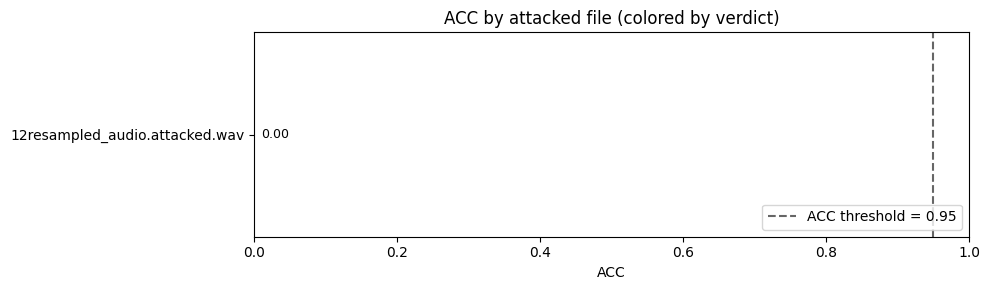

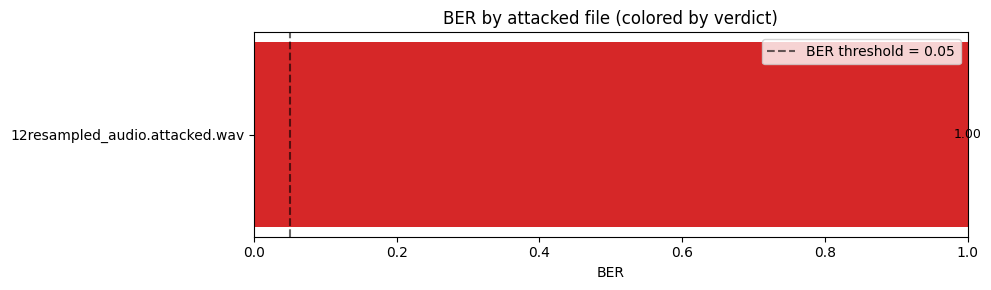

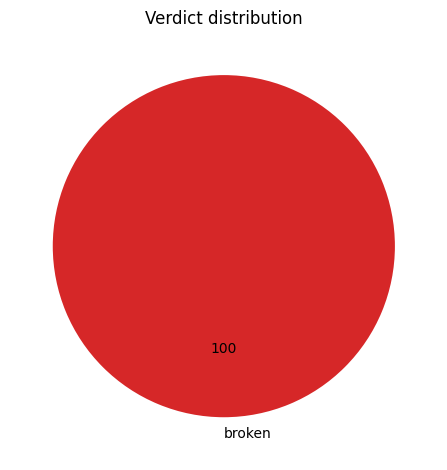

In [ ]:
# 4.5 · Visualization (force-inline, reset, display figures)

# 1) 强制 inline 后端 + 重置绘图状态
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np, pandas as pd, os, warnings, gc

assert 'df_eval' in globals() and not df_eval.empty, "df_eval is empty. Run 4.4 first."

# 2) 清理旧图、重置 rcParams、静音字体警告
plt.close('all'); gc.collect()
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore", module="matplotlib.font_manager")
warnings.filterwarnings("ignore", message=r"Glyph \d+ .*")

# 3) 准备数据（全英文标签）
dfv = df_eval.copy()
dfv["ACC"] = pd.to_numeric(dfv["ACC"], errors="coerce")
dfv["BER"] = pd.to_numeric(dfv["BER"], errors="coerce")
color_map = {"intact":"tab:green", "broken":"tab:red", "unverifiable":"tab:gray"}
dfv["color"] = dfv["verdict"].map(color_map).fillna("tab:gray")

# ================= Figure 1: ACC =================
sub = dfv.sort_values("ACC", ascending=True)
labels = [os.path.basename(str(x)) for x in sub["file"]]
y = np.arange(len(sub))
vals = sub["ACC"].fillna(0.0).to_numpy()

fig1, ax1 = plt.subplots(figsize=(10, max(3, 0.5*len(labels)+1)))
ax1.barh(y, vals, color=sub["color"])
ax1.set_yticks(y); ax1.set_yticklabels(labels)
ax1.set_xlabel("ACC"); ax1.set_xlim(0, 1)
ax1.axvline(0.95, ls="--", color="k", alpha=0.6, label="ACC threshold = 0.95")
for i, v in enumerate(vals):
    ax1.text(min(v+0.01, 0.98), i, f"{v:.2f}", va="center", fontsize=9)
ax1.legend(loc="lower right"); ax1.set_title("ACC by attacked file (colored by verdict)")
fig1.tight_layout()
display(fig1)

# ================= Figure 2: BER =================
sub2 = dfv.sort_values("BER", ascending=False)
labels2 = [os.path.basename(str(x)) for x in sub2["file"]]
y2 = np.arange(len(sub2))
vals2 = sub2["BER"].fillna(1.0).to_numpy()

fig2, ax2 = plt.subplots(figsize=(10, max(3, 0.5*len(labels2)+1)))
ax2.barh(y2, vals2, color=sub2["color"])
ax2.set_yticks(y2); ax2.set_yticklabels(labels2)
ax2.set_xlabel("BER"); ax2.set_xlim(0, 1)
ax2.axvline(0.05, ls="--", color="k", alpha=0.6, label="BER threshold = 0.05")
for i, v in enumerate(vals2):
    ax2.text(min(v+0.01, 0.98), i, f"{v:.2f}", va="center", fontsize=9)
ax2.legend(loc="upper right"); ax2.set_title("BER by attacked file (colored by verdict)")
fig2.tight_layout()
display(fig2)

# ================= Figure 3: Verdict pie =================
counts = dfv["verdict"].value_counts()

fig3, ax3 = plt.subplots(figsize=(4.8, 4.8))
ax3.pie(
    counts.values,
    labels=counts.index,
    autopct="%d",
    startangle=90,
    colors=[color_map.get(k, "tab:gray") for k in counts.index]
)
ax3.set_title("Verdict distribution")
fig3.tight_layout()
display(fig3)


# Section5：引入/复刻一类外部团队的攻击方法

## 5.1 · 攻击构件（贴纸合成 + 适配 RHDE 思想的 DE 搜索 + PGD 细化）

In [ ]:
# 5.1 · Audio "Sticker" + DE search + PGD refinement (RHDE-style, no L∞ projection)
import numpy as np, json, pathlib, math, random, gc, torch
import torch.nn.functional as F
import librosa, soundfile as sf
from scipy.signal import butter, sosfilt

TARGET_SR = h.sampling_rate

# ---- Utils: load/save ----
def load_wav_mono(path, target_sr=TARGET_SR):
    y, sr = librosa.load(path, sr=target_sr, mono=True, dtype=np.float32)
    if y.size == 0:
        raise ValueError(f"Empty audio: {path}")
    # peak norm to avoid clipping during search
    p = np.max(np.abs(y))
    if p > 0: y = 0.99 * y / p
    return y, target_sr

def save_wav(path, y, sr=TARGET_SR):
    y = np.clip(y, -1.0, 1.0).astype(np.float32)
    sf.write(path, y, sr)

def load_bits_from_wm_json(json_path):
    obj = json.loads(pathlib.Path(json_path).read_text())
    return np.array(obj.get("bits", []), dtype=np.int64)

# ---- Watermark loss (maximize to破坏水印) ----
def wm_ce_loss(x_tensor_1x1T, target_bits_np):
    """
    x_tensor_1x1T: [1,1,T] float32 in [-1,1]
    target_bits_np: np.array of {0,1}
    return: scalar BCE-with-logits loss (maximize 以破坏水印)
    """
    # mel 放到与音频相同的 device
    mel = mel_spectrogram(
        x_tensor_1x1T.squeeze(1),
        h.n_fft, h.num_mels, h.sampling_rate,
        h.hop_size, h.win_size, h.fmin, h.fmax_for_loss
    ).to(x_tensor_1x1T.device)

    # wm_dec 可能返回嵌套 tuple/list，这里“找出第一个 tensor 当作 logits”
    out = wm_dec(mel)
    sign_any = out[0] if isinstance(out, (list, tuple)) else out
    if isinstance(sign_any, (list, tuple)):
        sign_logits = None
        for elem in sign_any:
            if torch.is_tensor(elem):
                sign_logits = elem
                break
        if sign_logits is None:
            raise TypeError("wm_dec output does not contain a tensor logits.")
    else:
        sign_logits = sign_any

    # 目标张量放到与 logits 相同的 device
    tgt = torch.as_tensor(target_bits_np, dtype=torch.float32, device=sign_logits.device).view(1, -1)

    # 长度不一致时做安全对齐（取最短）
    L = min(sign_logits.shape[-1], tgt.shape[-1])
    sign_logits = sign_logits[..., :L]
    tgt        = tgt[..., :L]

    return F.binary_cross_entropy_with_logits(sign_logits, tgt)

# ---- "Sticker" generator: band-limited burst (or chirp) in a time window ----
def butter_bandpass_sos(low_hz, high_hz, sr, order=4):
    low = max(1.0, low_hz) / (sr*0.5)
    high = min(sr*0.5 - 10, high_hz) / (sr*0.5)
    high = max(high, low + 1e-4)
    return butter(order, [low, high], btype='band', output='sos')

def gen_band_limited_noise(n_samples, sr, f_center, bandwidth, envelope='hann'):
    # white noise -> bandpass
    wn = np.random.randn(n_samples).astype(np.float32)
    sos = butter_bandpass_sos(f_center - bandwidth/2.0, f_center + bandwidth/2.0, sr)
    bn = sosfilt(sos, wn).astype(np.float32)
    # windowing
    if envelope == 'hann':
        w = np.hanning(n_samples).astype(np.float32)
        bn *= w
    # peak norm
    p = np.max(np.abs(bn))
    if p > 1e-8: bn = bn / p
    return bn

def apply_audio_sticker(y, sr, t0, dur, amp, f_center, bandwidth):
    """
    y: np.float32 [-1,1]
    t0: start time in seconds
    dur: duration in seconds
    amp: global gain of the sticker
    f_center/bandwidth: in Hz
    """
    N = y.shape[0]
    start = int(round(t0 * sr))
    length = int(round(dur * sr))
    if length <= 8: return y.copy()  # too short, ignore
    start = np.clip(start, 0, max(0, N-1))
    end = np.clip(start+length, 0, N)
    sticker = gen_band_limited_noise(end-start, sr, f_center, bandwidth, envelope='hann')
    out = y.copy()
    out[start:end] = np.clip(out[start:end] + amp * sticker, -1.0, 1.0)
    return out

# ---- DE search over (t0, dur, fc, bw, amp) ----
@torch.no_grad()
def de_search(y_np, sr, gt_bits_np, pop_size=18, iters=18, seed=2025):
    """
    Return best params dict and attacked waveform (DE阶段，不做PGD).
    Params ranges:
      t0 ∈ [0, 0.9*len] s, dur ∈ [0.05, 0.6] s, fc ∈ [400, 6000] Hz, bw ∈ [200, 3200] Hz, amp ∈ [0.05, 0.6]
    """
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    T = y_np.shape[0] / sr
    def rand_ind():
        t0 = random.uniform(0.0, max(0.0, T*0.9))
        dur = random.uniform(0.03, min(0.15, max(0.06, T*0.3)))
        fc  = random.uniform(400.0, 6000.0)
        bw  = random.uniform(100.0, 600.0)
        amp = random.uniform(0.02, 0.2)
        return [t0, dur, fc, bw, amp]

    # init population
    pop = [rand_ind() for _ in range(pop_size)]
    def fitness(p):
        y_att = apply_audio_sticker(y_np, sr, *p)
        xt = torch.from_numpy(y_att).to(device).view(1,1,-1)
        # 目标是最大化“与GT相反”的CE，所以用 1 - gt_bits
        loss = wm_ce_loss(xt, 1 - gt_bits_np)
        # 返回“收益” = -loss，便于取最大
        return (-loss.item())

    scores = [fitness(p) for p in pop]
    Fm, Cr = 0.6, 0.7  # DE 超参
    for it in range(iters):
        for i in range(pop_size):
            idxs = list(range(pop_size)); idxs.remove(i)
            a, b, c = random.sample(idxs, 3)
            pa, pb, pc = pop[a], pop[b], pop[c]
            # mutate: pa + F*(pb - pc)
            cand = []
            for j in range(5):
                v = pa[j] + Fm * (pb[j] - pc[j])
                cand.append(v)
            # crossover
            trial = []
            for j, (cj, pj) in enumerate(zip(cand, pop[i])):
                if random.random() < Cr:
                    trial.append(cj)
                else:
                    trial.append(pj)
            # clamp ranges
            t0 = float(np.clip(trial[0], 0.0, T*0.9))
            dur= float(np.clip(trial[1], 0.03, min(0.15, T)))
            fc = float(np.clip(trial[2], 80.0, sr/2-200.0))
            bw = float(np.clip(trial[3], 100.0, 600))
            amp= float(np.clip(trial[4], 0.02, 0.2))
            trial = [t0,dur,fc,bw,amp]
            sc = fitness(trial)
            if sc > scores[i]:
                pop[i], scores[i] = trial, sc
        # 可选：print(f"DE iter {it+1}/{iters} best_score={max(scores):.4f}")
    best_idx = int(np.argmax(scores))
    best = pop[best_idx]
    y_best = apply_audio_sticker(y_np, sr, *best)
    return dict(t0=best[0], dur=best[1], fc=best[2], bw=best[3], amp=best[4]), y_best

# ---- PGD refinement on waveform window (no L∞ projection; only clamp) ----
def pgd_refine(y_start_np, sr, gt_bits_np, params, steps=40, step_size=0.005):
    """
    对 DE 找到的解起点做 PGD 梯度上升。
    仅做 clamp([-1,1])，不做 L∞ 投影（与“贴纸别被擦掉”的思路对应）。
    """
    # 显式开启梯度（你在 4.1 有 set_grad_enabled(False)）
    with torch.enable_grad():
        y = torch.from_numpy(y_start_np.copy()).to(device).view(1,1,-1)
        y.requires_grad_(True)

        for _ in range(steps):
            loss = wm_ce_loss(y, 1 - gt_bits_np)  # 破坏：朝着与 GT 相反的方向
            (-loss).backward()                    # maximize loss
            with torch.no_grad():
                g = torch.sign(y.grad)            # 符号梯度，稳定些
                y += step_size * g
                y.clamp_(-1.0, 1.0)
                y.grad.zero_()                    # 清梯度
        return y.detach().cpu().view(-1).numpy()



## 5.2 · 运行一次完整攻击并保存（输入 baseline.wav + 对应 .wm.json）

In [ ]:
# 5.2 · Attack runner: baseline -> (DE + PGD) -> attacked.wav
from google.colab import files

print("请上传：1) baseline 带水印音频（.wav）  2) 它的参考 .wm.json（同名或你自己指定）")
uploaded = files.upload()

# 选择 baseline 音频 & 参考 wm.json
audio_path = None
json_path = None
for k in uploaded.keys():
    suffix = pathlib.Path(k).suffix.lower()
    if suffix == ".wav": audio_path = k
    if suffix == ".json": json_path = k

assert audio_path is not None, "没有检测到 .wav"
assert json_path is not None, "没有检测到 .wm.json（参考位串）"

y0, sr = load_wav_mono(audio_path, TARGET_SR)
gt_bits = load_bits_from_wm_json(json_path)
print(f"Loaded: {audio_path}, len={len(y0)/sr:.2f}s; bits={gt_bits.tolist()}")

# === DE 阶段 ===
best_params, y_de = de_search(
    y0, sr, gt_bits, pop_size=18, iters=18, seed=2025
)
print("DE best:", best_params)

# === PGD 阶段（no L∞ projection, only clamp）===
y_adv = pgd_refine(
    y_de, sr, gt_bits, best_params, steps=40, step_size=0.005
)

# 保存并回显路径
out_path = pathlib.Path(audio_path).with_suffix(".attacked.wav").name
save_wav(out_path, y_adv, sr)
print("Saved attacked audio:", out_path)


请上传：1) baseline 带水印音频（.wav）  2) 它的参考 .wm.json（同名或你自己指定）


Saving 3resampled_audio.wav to 3resampled_audio.wav
Saving 3resampled_audio.wm.json to 3resampled_audio.wm.json
Loaded: 3resampled_audio.wav, len=14.37s; bits=[13, 9, 8, 7]
DE best: {'t0': 3.228940047610825, 'dur': 0.12868680694474924, 'fc': 2678.4533975718005, 'bw': 600.0, 'amp': 0.0877299182653325}
Saved attacked audio: 3resampled_audio.attacked.wav


# Section 6（Light 防御）

## 6.1 · 定义鲁棒解码（TTA + vote + 强同步）

In [ ]:
# ===== Section 6.1 · Robust decoding helpers (TTA + vote + strong sync) =====
import numpy as np, librosa, torch, json, pathlib, gc, glob
from collections import Counter
from scipy.signal import iirnotch, sosfiltfilt, zpk2sos

# 依赖于你在 4.1 已加载的 h / wm_dec / mel_spectrogram
TARGET_SR = h.sampling_rate
device = next(wm_dec.parameters()).device if hasattr(wm_dec, "parameters") else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ---- 基础预处理（Plain 解码会用到）----
def preprocess_audio(path, target_sr=TARGET_SR):
    y, sr = librosa.load(path, sr=target_sr, mono=True, dtype=np.float32)
    peak = np.max(np.abs(y)) if y.size else 0.0
    if peak > 0: y = 0.99 * y / peak
    return torch.from_numpy(y).to(device).view(1,1,-1)

# ---- librosa>=0.10 的重采样适配 ----
def _resample(y, sr_from, sr_to):
    return librosa.resample(y, orig_sr=sr_from, target_sr=sr_to)

# ---- TTA 变体 ----
def tta_variants(y, sr):
    def f32(a):  # helper: ensure np.float32
        return np.asarray(a, dtype=np.float32)

    y = f32(y)
    outs = [(y, sr)]

    # 轻度重采样 ±1%
    for scale in [0.99, 1.01]:
        sr_mid = int(sr * scale)
        ys = _resample(y, sr_from=sr, sr_to=sr_mid)
        ys = _resample(ys, sr_from=sr_mid, sr_to=sr)
        outs.append((f32(ys), sr))

    # 轻度音高 ±0.25 半音
    for st in [0.25, -0.25]:
        ys = librosa.effects.pitch_shift(y, sr=sr, n_steps=st)
        outs.append((f32(ys), sr))

    # 轻度时伸缩 ±3%
    for rate in [0.97, 1.03]:
        ys = librosa.effects.time_stretch(y, rate=rate)
        outs.append((f32(ys), sr))

    # 轻微噪声 -25 dB
    rms = float(np.sqrt(np.mean(y.astype(np.float64)**2) + 1e-12))  # 计算用64更稳，最后转回32
    noise = np.random.randn(len(y)).astype(np.float32) * (rms / (10 ** (25/20)))
    ys = np.clip(y + noise, -1, 1)
    outs.append((f32(ys), sr))
    return outs

# ---- 解码位串（取 logits>0）----
def decode_bits(x):
    mel = mel_spectrogram(
        x.float().squeeze(1),
        h.n_fft, h.num_mels, h.sampling_rate,
        h.hop_size, h.win_size, h.fmin, h.fmax_for_loss
    ).to(x.device)

    out = wm_dec(mel)
    # 优先使用第二个输出（与你 4.4 保持一致）
    if isinstance(out, (list, tuple)) and len(out) >= 2 and torch.is_tensor(out[1]):
        sign_hat = out[1]
    else:
        # 兜底：用 logits 阈值
        logits = out[0] if isinstance(out, (list, tuple)) else out
        if isinstance(logits, (list, tuple)):
            logits = next((e for e in logits if torch.is_tensor(e)), None)
            assert logits is not None, "wm_dec output has no tensor logits."
        sign_hat = (logits > 0).int()

    return sign_hat.detach().cpu().numpy().astype(int).reshape(-1)

# ---- 更稳健的 ACC/BER（带对齐）----
def acc_ber_safe(a, b, max_shift=64):
    if a is None or b is None: return None, None
    a = np.asarray(a).astype(int); b = np.asarray(b).astype(int)
    if a.size==0 or b.size==0: return None, None
    if a.size==b.size:
        return float((a==b).mean()), float((a!=b).mean())
    L = min(a.size, b.size); aL, bL = a[:L], b[:L]
    best = None
    # a 向右平移 s≥0
    for s in range(0, max_shift+1):
        k = L - s
        if k <= 0: break
        aa = aL[s:s+k]; bb = bL[:k]
        if aa.size and bb.size:
            ber = float((aa!=bb).mean())
            best = ber if best is None else min(best, ber)
    # b 向右平移 |s|（s<0）
    for s in range(-1, -max_shift-1, -1):
        d = -s; k = L - d
        if k <= 0: break
        aa = aL[:k]; bb = bL[d:d+k]
        if aa.size and bb.size:
            ber = float((aa!=bb).mean())
            best = ber if best is None else min(best, ber)
    if best is None: return None, None
    return 1.0 - best, best

# 新增：返回 logits（不做阈值）
def decode_logits(x):
    mel = mel_spectrogram(
        x.float().squeeze(1),
        h.n_fft, h.num_mels, h.sampling_rate,
        h.hop_size, h.win_size, h.fmin, h.fmax_for_loss
    ).to(x.device)
    out = wm_dec(mel)
    logits = out[0] if isinstance(out, (list,tuple)) else out
    if isinstance(logits, (list,tuple)):
        logits = next((e for e in logits if torch.is_tensor(e)), None)
    return logits.detach().cpu().numpy().reshape(-1).astype(np.float32)

# 用“logits 平均”做软投票
def robust_decode_vote_soft(wav_path, gt_bits=None, max_shift=256):
    y, sr = librosa.load(wav_path, sr=TARGET_SR, mono=True, dtype=np.float32)
    ys = [v[0] for v in tta_variants(y, sr)]

    # + 随机时间平移（增强同步）
    for s in np.linspace(-0.1, 0.1, 5):  # ±0.1s, 5 个平移
        shift = int(s * sr)
        ys.append(np.roll(y, shift).astype(np.float32))

    logits_list = []
    for yy in ys:
        peak = np.max(np.abs(yy)) if yy.size else 0.0
        if peak>0: yy = 0.99*yy/peak
        x = torch.from_numpy(yy.astype(np.float32)).to(device).view(1,1,-1)
        logits_list.append(decode_logits(x))
        del x

    L = min(map(len, logits_list))
    avg_logits = np.mean([l[:L] for l in logits_list], axis=0)
    voted = (avg_logits > 0).astype(int)

    acc, ber = acc_ber_safe(voted, gt_bits, max_shift=max_shift) if gt_bits is not None else (None, None)
    return voted, acc, ber

# ---- 读取参考位串 / 为 attacked 文件寻找参考 .wm.json ----
def load_bits_from_json(json_path):
    p = pathlib.Path(json_path)
    if p.exists():
        obj = json.loads(p.read_text())
        return np.array(obj.get("bits", []), dtype=int).reshape(-1)
    return None

# === 6.x · Confidence-driven adaptive notch (test-time defense) ===
def find_ref_bits_for(attacked_file):
    p = pathlib.Path(attacked_file)
    # 1) 同名 .wm.json
    cand = p.with_suffix(".wm.json")
    if cand.exists():
        return load_bits_from_json(cand)
    # 2) results_demo 或当前目录的任意一份 .wm.json
    cands = glob.glob("results_demo/*.wm.json") + glob.glob("*.wm.json")
    if cands:
        return load_bits_from_json(cands[0])
    return None

def conf_from_logits(logits):
    p = 1.0 / (1.0 + np.exp(-logits))               # sigmoid
    return float(np.mean(np.abs(p - 0.5)))           # 越大越自信

def apply_notch(y, sr, fc, Q):
    w0 = fc / (sr/2.0)
    # iirnotch → SOS，零相位 filtfilt（不改相位/对齐）
    b, a = iirnotch(w0, Q)
    # 将 (b,a) 转为 zpk 再到 sos，避免数值不稳（简版）
    import scipy.signal as sig
    z, p, k = sig.tf2zpk(b, a)
    sos = zpk2sos(z, p, k)
    y2 = sosfiltfilt(sos, y.astype(np.float64))
    return np.clip(y2, -1, 1).astype(np.float32)

def defend_adaptive_notch(wav_path, centers=range(1000,6001,250), Qs=(8,12,20), sr=TARGET_SR):
    y, _ = librosa.load(wav_path, sr=sr, mono=True, dtype=np.float32)
    y = (y / (np.max(np.abs(y))+1e-9)).astype(np.float32)

    # baseline 置信度
    x0 = torch.from_numpy(y).to(device).view(1,1,-1).float()
    best_conf = conf_from_logits(decode_logits(x0))
    best_bits = decode_bits(x0)

    # 扫描候选陷波
    for fc in centers:
        for Q in Qs:
            y2 = apply_notch(y, sr, fc, Q)
            x2 = torch.from_numpy(y2).to(device).view(1,1,-1).float()
            conf = conf_from_logits(decode_logits(x2))
            if conf > best_conf:                     # 只要“更自信”就采纳
                best_conf = conf
                best_bits = decode_bits(x2)
    return best_bits  # 返回防御后的位串



## 6.2 · 批量评测（Plain vs TTA）+ 可视化

,file,decoded_len,gt_len,ACC_plain,BER_plain,ACC_TTA,BER_TTA,ACC_gain,BER_drop
0,32resampled_audio.wav,4,4,1.0,0.0,0.0,1.0,-1.0,-1.0


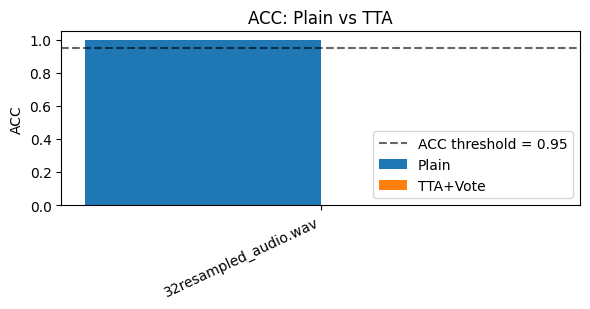

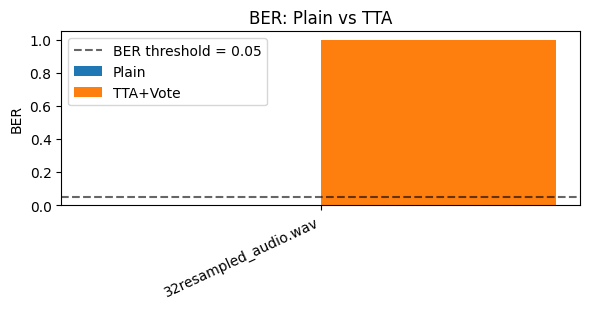

In [ ]:
# 6.2 · Evaluate Plain vs TTA vs Adaptive-Notch + plots (show-only)

from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np, pandas as pd, os, gc, warnings
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display

ACC_THR, BER_THR = 0.95, 0.05  # intact thresholds

# --- sanity checks: 依赖的函数应已在 6.1 定义 ---
need = ['preprocess_audio','decode_bits','acc_ber_safe','find_ref_bits_for','defend_adaptive_notch']
for k in need:
    assert k in globals(), f"Missing: {k}. Please run 6.1 first."
# TTA 软/硬投票择优
def run_tta(ap, gt):
    if 'robust_decode_vote_soft' in globals():
        return robust_decode_vote_soft(ap, gt_bits=gt, max_shift=256)
    elif 'robust_decode_vote' in globals():
        return robust_decode_vote(ap, gt_bits=gt, max_shift=64)
    else:
        return None, None, None  # 未定义则跳过

# 1) 选择要评测的 attacked 文件列表
attacked_files = []
if 'df_eval' in globals() and isinstance(df_eval, pd.DataFrame) and not df_eval.empty:
    attacked_files = [str(x) for x in df_eval['file'].tolist()]
elif 'attacks' in globals() and isinstance(attacks, (list,tuple)) and len(attacks)>0:
    attacked_files = list(attacks)

if not attacked_files:  # 还没有则上传
    from google.colab import files
    print("Upload attacked audio(s) (*.wav/*.mp3/*.m4a/*.flac).")
    up = files.upload()
    attacked_files = [k for k in up.keys() if os.path.splitext(k)[1].lower() in {'.wav','.mp3','.m4a','.flac'}]

assert attacked_files, "No attacked files found."

# 2) 评测
rows = []
for ap in attacked_files:
    gt = find_ref_bits_for(ap)
    if gt is None or len(gt) == 0:
        print(f"Skip (no/empty reference bits): {ap}")
        continue

    # Plain
    x = preprocess_audio(ap); dec = decode_bits(x)
    acc_plain, ber_plain = acc_ber_safe(dec, gt, max_shift=64)

    # TTA：若 Plain 已达标，则沿用 Plain；否则运行 TTA
    if (acc_plain is not None and ber_plain is not None and acc_plain >= ACC_THR and ber_plain <= BER_THR):
        acc_tta, ber_tta = acc_plain, ber_plain
    else:
        _, acc_tta, ber_tta = run_tta(ap, gt)

    # Adaptive Notch（置信度驱动陷波）
    dec_notch = defend_adaptive_notch(ap)
    acc_notch, ber_notch = acc_ber_safe(dec_notch, gt, max_shift=64)

    rows.append((
        os.path.basename(ap), len(dec), len(gt),
        acc_plain, ber_plain,
        acc_tta,   ber_tta,
        acc_notch, ber_notch,
        (None if acc_plain is None or acc_tta   is None else acc_tta   - acc_plain),
        (None if ber_plain is None or ber_tta   is None else ber_plain - ber_tta),
        (None if acc_plain is None or acc_notch is None else acc_notch - acc_plain),
        (None if ber_plain is None or ber_notch is None else ber_plain - ber_notch),
    ))

    del x
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()

df_def = pd.DataFrame(rows, columns=[
    "file","decoded_len","gt_len",
    "ACC_plain","BER_plain",
    "ACC_TTA","BER_TTA",
    "ACC_notch","BER_notch",
    "ACC_gain_TTA","BER_drop_TTA",
    "ACC_gain_notch","BER_drop_notch"
])
assert not df_def.empty, "No rows to show. Check your inputs."
display(df_def.sort_values("ACC_notch", ascending=False))

# 3) 只显示图（三列：Plain / TTA / Notch）
plt.close('all'); gc.collect()
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore", module="matplotlib.font_manager")

labels = df_def["file"].tolist()
xpos   = np.arange(len(labels))
w = 0.25

# ACC
fig1, ax1 = plt.subplots(figsize=(max(6, 0.9*len(labels)+2), 3.2))
ax1.bar(xpos - w, df_def["ACC_plain"].fillna(0.0), width=w, label="Plain")
ax1.bar(xpos,     df_def["ACC_TTA"].fillna(0.0),   width=w, label="TTA+Vote")
ax1.bar(xpos + w, df_def["ACC_notch"].fillna(0.0), width=w, label="Adaptive Notch")
ax1.axhline(ACC_THR, ls="--", color="k", alpha=0.6, label=f"ACC thr = {ACC_THR}")
ax1.set_xticks(xpos); ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.set_ylim(0, 1.05); ax1.set_ylabel("ACC"); ax1.set_title("ACC: Plain vs TTA vs Notch")
ax1.legend(); fig1.tight_layout()
display(fig1)

# BER
fig2, ax2 = plt.subplots(figsize=(max(6, 0.9*len(labels)+2), 3.2))
ax2.bar(xpos - w, df_def["BER_plain"].fillna(1.0), width=w, label="Plain")
ax2.bar(xpos,     df_def["BER_TTA"].fillna(1.0),   width=w, label="TTA+Vote")
ax2.bar(xpos + w, df_def["BER_notch"].fillna(1.0), width=w, label="Adaptive Notch")
ax2.axhline(BER_THR, ls="--", color="k", alpha=0.6, label=f"BER thr = {BER_THR}")
ax2.set_xticks(xpos); ax2.set_xticklabels(labels, rotation=25, ha="right")
ax2.set_ylim(0, 1.05); ax2.set_ylabel("BER"); ax2.set_title("BER: Plain vs TTA vs Notch")
ax2.legend(); fig2.tight_layout()
display(fig2)

#Section 7: Experimental reproducibility and safety Settings

Random seed & cuDNN Settings, ensure the experiment can be reproduced

In [ ]:
import torch, random, numpy as np
seed = 2025
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

import torch
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Checkpoint file backup (Ensuring model security and no loss)

In [ ]:
import shutil

src = "WMCodec_hc/save_model/g_00150000"       # Orignial path
dst = "WMCodec_hc/save_model/g_00150000.bak.pth"   # The new name of the backup file

shutil.copy2(src, dst)   # Copy the file and try to retain metadata such as the modification time and permissions
print(f"Backed up: {src} → {dst}")

Clean the /input_audio directory (if there has '.ipynb_checkpoints' in /input_audio you will need this code)

In [ ]:
import os, shutil, glob

# Delete the checkpoint directory automatically generated by Colab
shutil.rmtree("/content/input_audio/.ipynb_checkpoints", ignore_errors=True)

# Only keep the *.wav file (delete or remove other suffixes first)
for p in glob.glob("/content/input_aduio/*"):
    if os.path.isdir(p):
        shutil.rmtree(p, ignore_errors=True)
    elif not p.lower().endswith(".wav"):
        os.remove(p)

# Check
wavs = [p for p in glob.glob("/content/input_audio/*.wav") if os.path.isfile(p)]
print("found wavs:", len(wavs), wavs[:5])
